In [28]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["TAVILY_API_KEY"]= os.getenv("TAVILY_API_KEY")

os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")

model= ChatGroq(model= "qwen/qwen3.6-27b")


In [30]:
from langchain_tavily import TavilySearch

tavily_search_tool= TavilySearch(
    max_results= 5,
    topic= "general"
)

tavily_search_tool.invoke("What is the current AI News?")

{'query': 'What is the current AI News?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.wsj.com/tech/ai',
   'title': 'Artificial Intelligence - Latest AI News and Analysis',
   'content': 'EU Says TikTok Accounts for Minors Might Breach Bloc’s Digital Rules. The European Commission provisionally found TikTok’s rules for minors’ accounts didn’t meet its bloc’s safety standards. Inside China’s All-Out Push to Catch Up With American AI Chips. The incident serves as an early example of loss-of-control scenarios long feared by artificial-intelligence safety researchers. Stripe in Talks to Buy Buzzy AI-Model Marketplace OpenRouter. The French company agreed to buy the U.S. supplier of software to the life-sciences industry, as it seeks to bolster its artificial-intelligence offering. ### OpenAI’s Planned Cloud Spending Hits $750 Billion as Computing Efforts Ramp Up. The AI giant has committed $20 billion to a new data-center project in Georg

In [31]:
from langchain.tools import tool

@tool("calculator", description="Performance arithmetic calculations. Use this for any math problem.")
def calc(expression: str) -> str:
    """Evaluate a math expression."""
    return str(eval(expression))

In [32]:
from langchain.agents import create_agent

agent =create_agent(
    model=model,
    tools=[tavily_search_tool, calc]
)

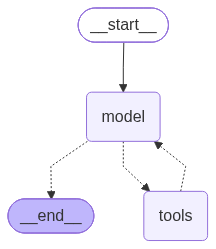

In [33]:
agent

In [34]:
user_input= "What is the current AI news for Anthropic then calculate 5 + 3?"

for step in agent.stream(
    {"messages": user_input},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current AI news for Anthropic then calculate 5 + 3?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (f7mhny94w)
 Call ID: f7mhny94w
  Args:
    query: Anthropic AI news
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "Anthropic AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ainews.it/tag/anthropic/feed", "title": "anthropic - AI News", "content": "Title: anthropic - AI News\nanthropic - AI News https://ainews.it/tag/anthropic/ AI News: Notizie intelligenza artificiale Fri, 27 Mar 2026 08:42:33 +0000 it-IT  hourly   1  https://wordpress.org/? v=6.9.4  https://ainews.it/wp-content/uploads/2022/07/cropped-Favicon\\_Ai\\_2-011-150x150.png anthropic - AI News https://ainews.it/tag/anthropic/ 32 32  USA, 

In [37]:
agent.invoke({"messages": "AI NEWS"})['messages'][-1].pretty_print()

================================== Ai Message ==================================
